# IEEE 34 Node

In [7]:
import sys
from pathlib import Path
import py_dss_interface
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

from unit_converter import UnitConverter
from fault import FaultSimulator
from topologia import FeederTopology
from locator import FaultLocator

In [2]:
BASE_DIR = Path("..").resolve()
BASE_DIR

WindowsPath('D:/UFC/LOCALIZACAO-DE-FALTAS/refatorando-codigo/tcc-luis-felipe')

In [3]:
DSS_FILE = BASE_DIR / "data" / "34Bus" / "Run_IEEE34Mod1.dss"
DSS_FILE

WindowsPath('D:/UFC/LOCALIZACAO-DE-FALTAS/refatorando-codigo/tcc-luis-felipe/data/34Bus/Run_IEEE34Mod1.dss')

## Aplicação da metodologia

In [4]:
simulador = FaultSimulator(str(DSS_FILE), origin_bus='800', target_kv=14.37)
simulador.topology.print_circuits_info()


🗺️  RESUMO DA TOPOLOGIA DOS CIRCUITOS MAPEADOS

C_1: L = 42.34 | Q = 4 | seçoes: [L1-L2-L3-L4]
C_2: L = 117.33 | Q = 9 | seçoes: [L1-L2-L3-L5-L6-L7-L24-L9-L12]
C_3: L = 167.69 | Q = 10 | seçoes: [L1-L2-L3-L5-L6-L7-L24-L8-L10-L11]
C_4: L = 159.43 | Q = 12 | seçoes: [L1-L2-L3-L5-L6-L7-L24-L9-L13-L14-L15-L26]
C_5: L = 179.46 | Q = 15 | seçoes: [L1-L2-L3-L5-L6-L7-L24-L9-L13-L14-L15-L27-L25-L16-L28]
C_6: L = 189.23 | Q = 18 | seçoes: [L1-L2-L3-L5-L6-L7-L24-L9-L13-L14-L15-L27-L25-L16-L29-L17-L30-L19]
C_7: L = 189.47 | Q = 19 | seçoes: [L1-L2-L3-L5-L6-L7-L24-L9-L13-L14-L15-L27-L25-L16-L29-L18-L21-L22-L23]
C_8: L = 193.51 | Q = 19 | seçoes: [L1-L2-L3-L5-L6-L7-L24-L9-L13-L14-L15-L27-L25-L16-L29-L17-L30-L20-L31]




In [5]:
simulador = FaultSimulator(str(DSS_FILE), origin_bus='800', target_kv=14.37)

# 3. (Opcional) Imprime o resumo da topologia descoberta automaticamente
# Isso chamará aquele método de print bonito que configuramos na FeederTopology

# 4. Configura os parâmetros da varredura
# Varrendo a linha de 10% em 10%
passo_distancia = 0.30  
passo_distancia_m = 50.0

# Lista de resistências de falta (em Ohms)
resistencias_falta = [0.0001, 10.0, 20.0, 30.0, 40.0]  
# resistencias_falta = [0.0001]  

# 5. Executa o laço principal da simulação
print("\nIniciando a varredura linear de curtos-circuitos...")

simulador.run_simulation(step_abs_m=passo_distancia_m, r_list=resistencias_falta)

localizador = FaultLocator(str(DSS_FILE), simulador.topology,
                           pd.DataFrame(simulador.results))

localizador.run_minimum_reactance()

localizador.apply_mi_filter()



Iniciando a varredura linear de curtos-circuitos...


Aplicando Filtro MI: 100%|██████████| 62145/62145 [00:03<00:00, 18490.49it/s]


In [6]:
localizador.df

,va_r,va_i,vb_r,vb_i,vc_r,vc_i,ia_r,ia_i,ib_r,ib_i,...,circuito_5_line,circuito_6_d,circuito_6_line,circuito_7_d,circuito_7_line,circuito_8_d,circuito_8_line,linha_estimada,dist_estimada,erro_percentual
0,14176.031953,-601.531341,-7328.570585,-12952.706480,-7328.288598,13192.202526,163764.037424,-177498.929473,-20.412232,-29.766292,...,l1,50.000077,l1,50.000076,l1,50.000076,l1,l1,50.000078,1.349468e-07
1,15085.867327,-248.598742,-7595.239576,-11979.652859,-7556.137927,12824.176241,37.038968,-3.123443,-235312.101775,-49969.648684,...,l1,50.000064,l1,50.000064,l1,50.000063,l1,l1,50.000066,1.139939e-07
2,14883.032194,130.806446,-7759.274793,-12941.356548,-6572.701340,12571.814313,39.403020,-4.366007,-17.697516,-28.039087,...,l1,50.000060,l1,50.000060,l1,50.000060,l1,l1,50.000061,1.049866e-07
3,14566.162418,-1482.597008,-7019.038442,-11589.948607,-7547.159834,13072.549048,278483.528904,-45598.967910,-278466.570059,45544.394987,...,l1,50.000058,l1,50.000058,l1,50.000058,l1,l1,50.000058,1.000220e-07
4,15094.713484,-0.297325,-8441.899313,-11878.511205,-6652.821071,11878.800104,56.597975,-10.213400,-181843.573912,-196137.850518,...,l1,50.000054,l1,50.000054,l1,50.000053,l1,l1,50.000054,9.347661e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62140,15094.775925,-0.400838,-7547.727818,-13071.692122,-7547.195082,13072.427566,47.730419,-7.169197,-156.795379,-93.559644,...,l27,48594.264000,l26,51355.369115,l27,51389.888883,l27,l27,51391.730884,-1.274239e+01
62141,15094.775886,-0.400773,-7547.727663,-13071.692437,-7547.195104,13072.427629,47.733882,-7.170729,-156.731277,-93.514631,...,l27,48594.264000,l26,51382.150176,l27,51416.691921,l27,l27,51418.534513,-1.278256e+01
62142,15094.775846,-0.400709,-7547.727508,-13071.692751,-7547.195125,13072.427693,47.737341,-7.172260,-156.667238,-93.469686,...,l27,48594.264000,l26,51408.919136,l27,51443.471852,l27,l27,51445.315037,-1.282276e+01
62143,15094.775807,-0.400644,-7547.727353,-13071.693065,-7547.195147,13072.427757,47.740796,-7.173791,-156.603262,-93.424808,...,l27,48594.264000,l26,51435.664962,l27,51470.228703,l27,l27,51472.072484,-1.286301e+01


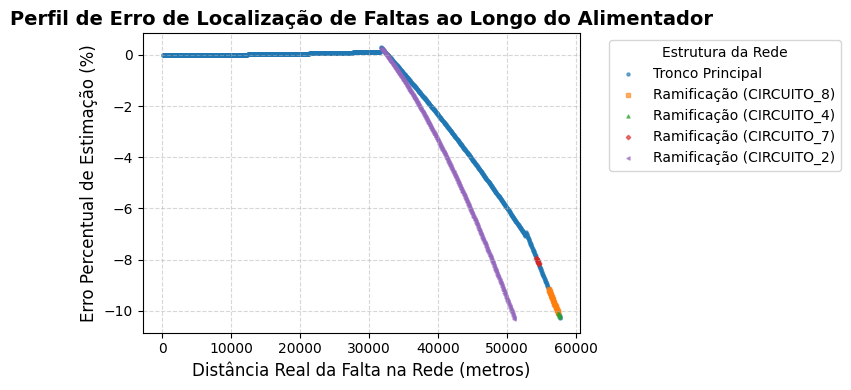

In [7]:

import matplotlib.pyplot as plt

"""
Gera um gráfico do erro percentual em função da distância.
Plota primeiro o tronco principal e depois as ramificações exclusivas de cada circuito.
"""
plt.figure(figsize=(8, 4))

# 1. Ordena os circuitos do maior para o menor (em quantidade de seções)
# O maior será naturalmente o "tronco principal"
circuitos_ordenados = sorted(localizador.topology.main_circuits.items(), key=lambda item: len(item[1]), reverse=True)

# Conjunto para rastrear quais linhas já foram plotadas
linhas_plotadas = set()

# Paleta de marcadores para diferenciar visualmente os ramais
marcadores = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'X']

for idx, (nome_circuito, linhas) in enumerate(circuitos_ordenados):
    # 2. Filtra as linhas: pega apenas as que AINDA NÃO estão no tronco/ramais anteriores
    linhas_do_ramal = [linha for linha in linhas if linha not in linhas_plotadas]
    
    if not linhas_do_ramal:
        continue # Se todas as linhas já foram plotadas (circuito 100% redundante), pula.
        
    # 3. Filtra o DataFrame para pegar as distâncias e erros dessas linhas específicas
    df_ramal = localizador.df[localizador.df['linha_faltosa'].isin(linhas_do_ramal)]
    # Exemplo se quisesse filtrar:
    df_ramal = localizador.df[(localizador.df['linha_faltosa'].isin(linhas_do_ramal)) & (localizador.df['tipo'] == 'at') & (localizador.df['r'] == 0.0001)]
    
    if df_ramal.empty:
        continue
        
    # Define o nome para a legenda
    label_nome = "Tronco Principal" if idx == 0 else f"Ramificação ({nome_circuito.upper()})"
    
    # 4. Plota os dados em gráfico de dispersão (Scatter)
    # Scatter é ideal porque para uma mesma distância temos vários erros (tipos de falta e resistências diferentes)
    plt.scatter(df_ramal['distancia'], df_ramal['erro_percentual'], label=label_nome, marker=marcadores[idx % len(marcadores)], alpha=0.6, s=5)
    
    # 5. Adiciona as linhas desenhadas ao conjunto de bloqueio
    linhas_plotadas.update(linhas_do_ramal)

# Configurações de estética do gráfico
plt.title('Perfil de Erro de Localização de Faltas ao Longo do Alimentador', fontsize=14, fontweight='bold')
plt.xlabel('Distância Real da Falta na Rede (metros)', fontsize=12)
plt.ylabel('Erro Percentual de Estimação (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Coloca a legenda fora do gráfico para não sobrepor os dados
plt.legend(title='Estrutura da Rede', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() # Ajusta as margens automaticamente

# # Salva o gráfico ou exibe na tela
# if save_path:
#     Path(save_path).parent.mkdir(parents=True, exist_ok=True)
#     plt.savefig(save_path, dpi=300, bbox_inches='tight')
#     print(f"📊 Gráfico gerado e salvo com sucesso em: {save_path}")
# else:
plt.show()

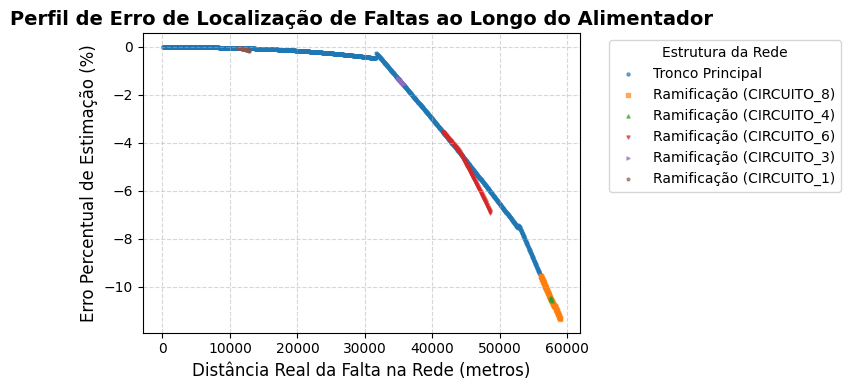

In [ ]:


"""
Gera um gráfico do erro percentual em função da distância.
Plota primeiro o tronco principal e depois as ramificações exclusivas de cada circuito.
"""
plt.figure(figsize=(8, 4))

# 1. Ordena os circuitos do maior para o menor (em quantidade de seções)
# O maior será naturalmente o "tronco principal"
circuitos_ordenados = sorted(localizador.topology.main_circuits.items(), key=lambda item: len(item[1]), reverse=True)

# Conjunto para rastrear quais linhas já foram plotadas
linhas_plotadas = set()

# Paleta de marcadores para diferenciar visualmente os ramais
marcadores = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'X']

for idx, (nome_circuito, linhas) in enumerate(circuitos_ordenados):
    # 2. Filtra as linhas: pega apenas as que AINDA NÃO estão no tronco/ramais anteriores
    linhas_do_ramal = [linha for linha in linhas if linha not in linhas_plotadas]
    
    if not linhas_do_ramal:
        continue # Se todas as linhas já foram plotadas (circuito 100% redundante), pula.
        
    # 3. Filtra o DataFrame para pegar as distâncias e erros dessas linhas específicas
    df_ramal = localizador.df[localizador.df['linha_faltosa'].isin(linhas_do_ramal)]
    # Exemplo se quisesse filtrar:
    df_ramal = localizador.df[(localizador.df['linha_faltosa'].isin(linhas_do_ramal)) & (localizador.df['tipo'] == 'bt') & (localizador.df['r'] == 0.0001)]
    
    if df_ramal.empty:
        continue
        
    # Define o nome para a legenda
    label_nome = "Tronco Principal" if idx == 0 else f"Ramificação ({nome_circuito.upper()})"
    
    # 4. Plota os dados em gráfico de dispersão (Scatter)
    # Scatter é ideal porque para uma mesma distância temos vários erros (tipos de falta e resistências diferentes)
    plt.scatter(df_ramal['distancia'], df_ramal['erro_percentual'], label=label_nome, marker=marcadores[idx % len(marcadores)], alpha=0.6, s=5)
    
    # 5. Adiciona as linhas desenhadas ao conjunto de bloqueio
    linhas_plotadas.update(linhas_do_ramal)

# Configurações de estética do gráfico
plt.title('Perfil de Erro de Localização de Faltas ao Longo do Alimentador', fontsize=14, fontweight='bold')
plt.xlabel('Distância Real da Falta na Rede (metros)', fontsize=12)
plt.ylabel('Erro Percentual de Estimação (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Coloca a legenda fora do gráfico para não sobrepor os dados
plt.legend(title='Estrutura da Rede', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() # Ajusta as margens automaticamente

# # Salva o gráfico ou exibe na tela
# if save_path:
#     Path(save_path).parent.mkdir(parents=True, exist_ok=True)
#     plt.savefig(save_path, dpi=300, bbox_inches='tight')
#     print(f"📊 Gráfico gerado e salvo com sucesso em: {save_path}")
# else:
plt.show()

In [9]:
localizador.export_results(
    output_dir= BASE_DIR / "result",
    filename= "ieee_34_node_result_50m.csv"
)

✅ Análise concluída. Resultados salvos em: C:\Users\GREI-Luis-Felipe\Documents\GitHub\tcc-luis-felipe\result\ieee_34_node_result_50m.csv


## Análise dos resultados

In [6]:
results_df = pd.read_csv(BASE_DIR / "result" / "ieee_34_node_result_50m.csv", sep=";", decimal=",")
results_df.head()

,va_r,va_i,vb_r,vb_i,vc_r,vc_i,ia_r,ia_i,ib_r,ib_i,...,circuito_5_line,circuito_6_d,circuito_6_line,circuito_7_d,circuito_7_line,circuito_8_d,circuito_8_line,linha_estimada,dist_estimada,erro_percentual
0,14176.031953,-601.531341,-7328.570585,-12952.706480,-7328.288598,13192.202526,163764.037424,-177498.929473,-20.412232,-29.766292,...,l1,50.000077,l1,50.000076,l1,50.000076,l1,l1,50.000078,1.349468e-07
1,15085.867327,-248.598742,-7595.239576,-11979.652859,-7556.137927,12824.176241,37.038968,-3.123443,-235312.101775,-49969.648684,...,l1,50.000064,l1,50.000064,l1,50.000063,l1,l1,50.000066,1.139939e-07
2,14883.032194,130.806446,-7759.274793,-12941.356548,-6572.701340,12571.814313,39.403020,-4.366007,-17.697516,-28.039087,...,l1,50.000060,l1,50.000060,l1,50.000060,l1,l1,50.000061,1.049866e-07
3,14566.162418,-1482.597008,-7019.038442,-11589.948607,-7547.159834,13072.549048,278483.528904,-45598.967910,-278466.570059,45544.394987,...,l1,50.000058,l1,50.000058,l1,50.000058,l1,l1,50.000058,1.000220e-07
4,15094.713484,-0.297325,-8441.899313,-11878.511205,-6652.821071,11878.800104,56.597975,-10.213400,-181843.573912,-196137.850518,...,l1,50.000054,l1,50.000054,l1,50.000053,l1,l1,50.000054,9.347661e-08


In [8]:
results_df.columns

Index(['va_r', 'va_i', 'vb_r', 'vb_i', 'vc_r', 'vc_i', 'ia_r', 'ia_i', 'ib_r',
       'ib_i', 'ic_r', 'ic_i', 'linha_faltosa', 'distancia', 'tipo', 'r',
       'l1_ia', 'l1_ib', 'l1_ic', 'l4_ia', 'l4_ib', 'l4_ic', 'l5_ia', 'l5_ib',
       'l5_ic', 'l8_ia', 'l8_ib', 'l8_ic', 'l9_ia', 'l9_ib', 'l9_ic', 'l12_ia',
       'l12_ib', 'l12_ic', 'l13_ia', 'l13_ib', 'l13_ic', 'l26_ia', 'l26_ib',
       'l26_ic', 'l27_ia', 'l27_ib', 'l27_ic', 'l28_ia', 'l28_ib', 'l28_ic',
       'l29_ia', 'l29_ib', 'l29_ic', 'l17_ia', 'l17_ib', 'l17_ic', 'l18_ia',
       'l18_ib', 'l18_ic', 'l19_ia', 'l19_ib', 'l19_ic', 'l20_ia', 'l20_ib',
       'l20_ic', 'circuito_1_d', 'circuito_1_line', 'circuito_2_d',
       'circuito_2_line', 'circuito_3_d', 'circuito_3_line', 'circuito_4_d',
       'circuito_4_line', 'circuito_5_d', 'circuito_5_line', 'circuito_6_d',
       'circuito_6_line', 'circuito_7_d', 'circuito_7_line', 'circuito_8_d',
       'circuito_8_line', 'linha_estimada', 'dist_estimada',
       'erro_percent

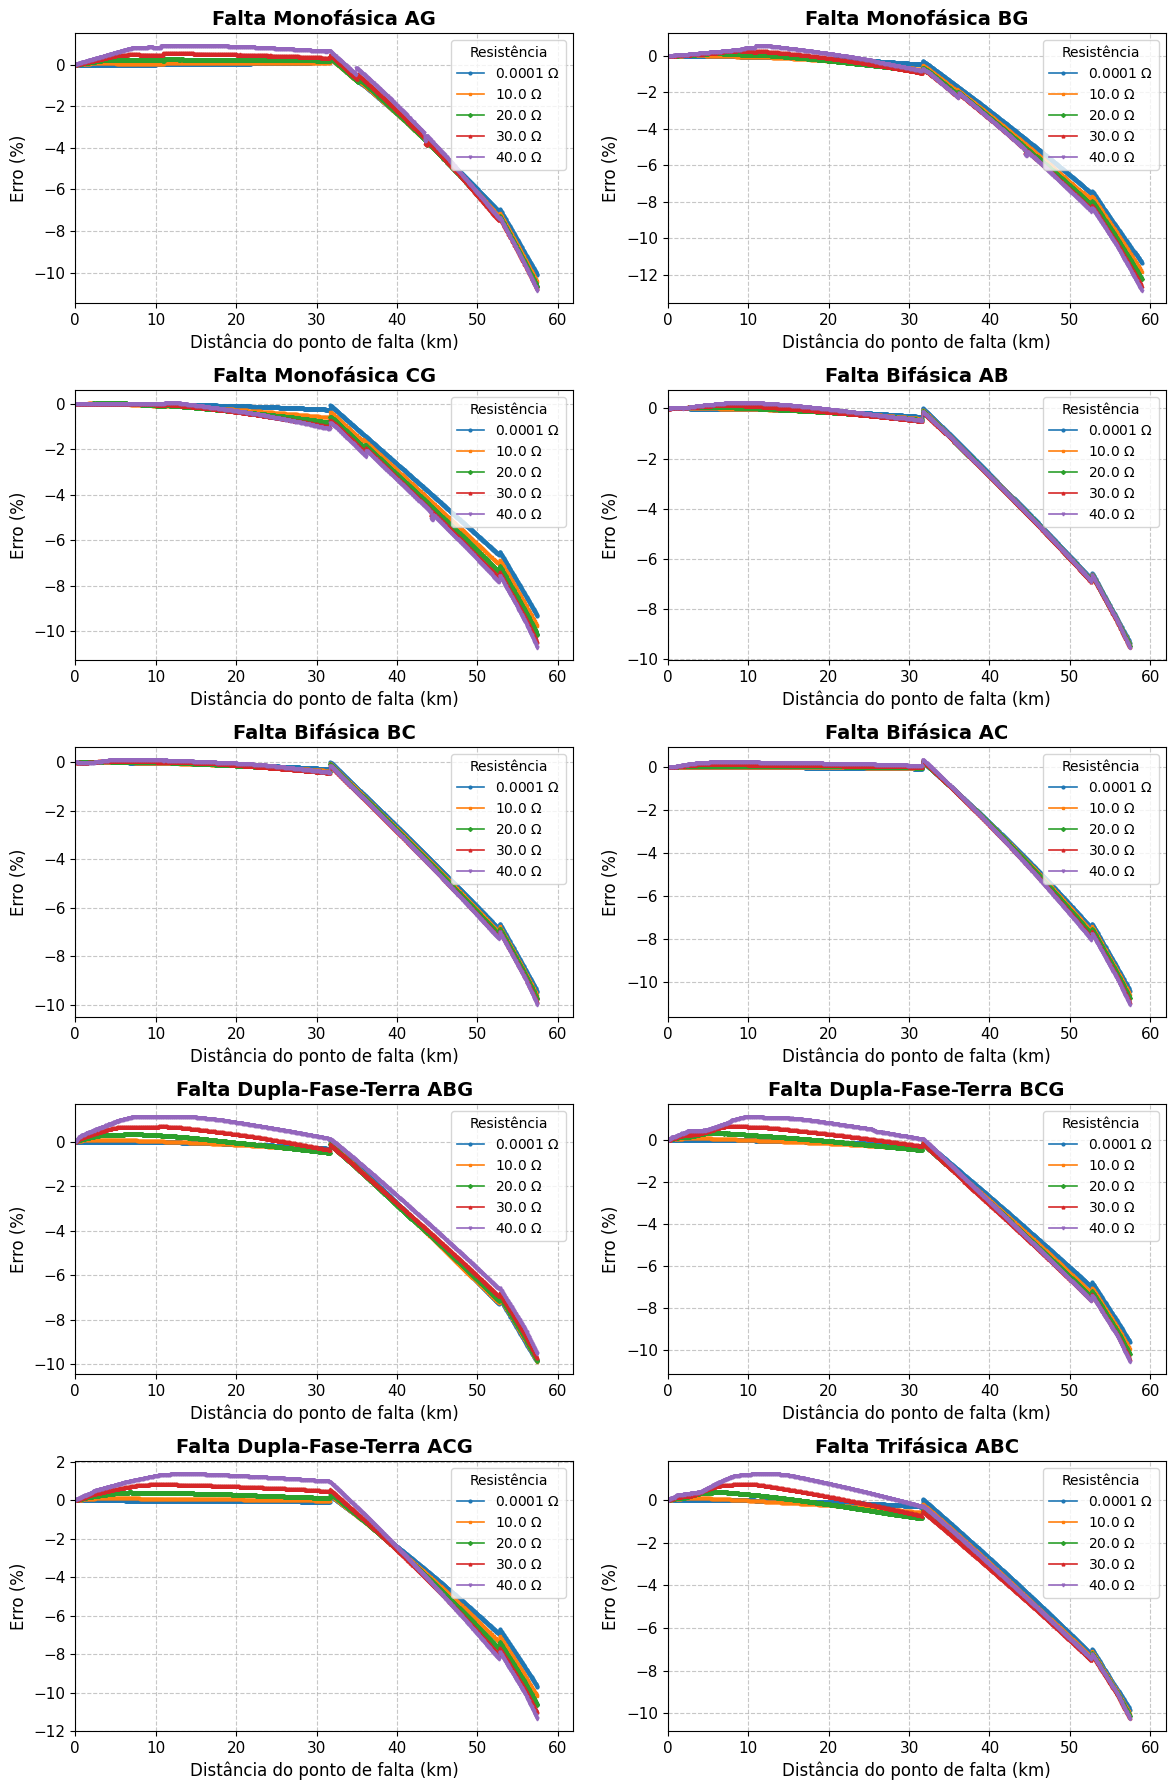

In [13]:
mapa_faltas = {
    'at': 'Falta Monofásica AG', 'bt': 'Falta Monofásica BG', 'ct': 'Falta Monofásica CG',
    'ab': 'Falta Bifásica AB', 'bc': 'Falta Bifásica BC', 'ac': 'Falta Bifásica AC',
    'abt': 'Falta Dupla-Fase-Terra ABG', 'bct': 'Falta Dupla-Fase-Terra BCG', 'act': 'Falta Dupla-Fase-Terra ACG', 
    'abc': 'Falta Trifásica ABC'
}

# Lista de linhas do ramal principal
ramal_principal = simulador.topology.get_main_branch()
markers = ['o', 's', 'D', '^', 'v']

# Configuração rigorosa do Matplotlib preservada
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 10

# --- 2. EXTRAÇÃO DE PARÂMETROS DINÂMICOS ---
col_resistencia = 'r_f' if 'r_f' in results_df.columns else 'r'
resistencias_simuladas = sorted(results_df[col_resistencia].unique())

# Calcula o limite máximo do eixo X
limite_x_km = (results_df[results_df['linha_faltosa'].isin(ramal_principal)]['distancia'].max() / 1000.0) * 1.05

# --- 3. GERAÇÃO DO GRID DE GRÁFICOS ---
# Cria a figura e a matriz de eixos (5 linhas x 2 colunas)
# Aumentamos o figsize verticalmente para os gráficos não ficarem esmagados
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 18))

# Achata a matriz 2D de eixos para uma lista 1D, facilitando o loop
axes = axes.flatten() 

for ax, (tipo_falta, titulo_grafico) in zip(axes, mapa_faltas.items()):
    
    # Filtra apenas o tipo de falta atual e as linhas do ramal principal
    df_tipo = results_df[(results_df['tipo'] == tipo_falta) & (results_df['linha_faltosa'].isin(ramal_principal))].copy()
    
    # Tratamento caso a rede não possua alguma fase simulada (ex: falta CG num trecho sem fase C)
    if df_tipo.empty:
        ax.set_title(f"{titulo_grafico} (Sem dados simulados)")
        ax.axis('off') # Esconde as bordas do gráfico vazio
        continue

    # Iterar sobre as resistências simuladas para criar cada curva
    for i, res in enumerate(resistencias_simuladas):
        df_plot = df_tipo[df_tipo[col_resistencia] == res].copy()
        if df_plot.empty:
            continue

        # Converter metros para quilômetros
        df_plot['distancia_km'] = df_plot['distancia'] / 1000.0
        
        # ORDENAÇÃO: Impede que a linha do gráfico faça zigue-zague
        df_plot = df_plot.sort_values(by='distancia_km')

        # Plotando direto no eixo atual (ax) em vez de plt
        marker_estilo = markers[i % len(markers)]
        ax.plot(df_plot['distancia_km'], 
                df_plot['erro_percentual'], 
                marker=marker_estilo, 
                markersize=2, 
                linestyle='-', 
                linewidth=1.2, 
                label=f'{res} $\\Omega$')

    # Configurações individuais do subplot atual
    ax.set_title(titulo_grafico, fontweight='bold')
    ax.set_xlim(0, limite_x_km)
    
    # Adicionamos rótulos nos eixos
    ax.set_xlabel("Distância do ponto de falta (km)")
    ax.set_ylabel("Erro (%)")
    
    ax.legend(title="Resistência", loc='upper right')
    ax.grid(True, linestyle="--", alpha=0.7)

# Ajusta automaticamente o espaçamento para que títulos e eixos não se sobreponham
plt.tight_layout()

# Exibe o grid na tela
plt.show()